# Exploratory Data Analysis (EDA)

**Project:** Vancouver Property Value Prediction

**Notebook goal:** Deep statistical and visual exploration of the dataset to:
1. Understand the target variable distribution
2. Identify the most predictive features (location, zoning, property type, age)
3. Discover insights about Vancouver's real estate market
4. Detect outliers and data quality issues
5. Generate hypotheses to validate during modeling

**Author:** Rafael Carrillo Mirabal

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load the dataset
df = pd.read_parquet("../data/raw/property_tax_report.parquet")

# Create target variable
df['total_value'] = df['current_land_value'] + df['current_improvement_value']

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded: 1,552,663 rows × 31 columns


## 1. Focus the analysis on the most recent year

The dataset spans 2020–2026. For the EDA, we focus on **2026** (the most recent year) to:
- Avoid temporal price drift confusing patterns
- Get the most current picture of the Vancouver market
- Have a clean snapshot for visualization

Historical years will be useful later for trend analysis.

In [2]:
# Filter to the most recent year
df_2026 = df[df['report_year'] == '2026'].copy()

# Remove rows with zero or null target (cannot analyze them)
df_2026 = df_2026[df_2026['total_value'] > 0].copy()

print(f"Records for 2026: {len(df_2026):,}")
print(f"Records after removing zero/null values: {len(df_2026):,}")
print(f"Total value range: ${df_2026['total_value'].min():,.0f} to ${df_2026['total_value'].max():,.0f}")

Records for 2026: 223,557
Records after removing zero/null values: 223,557
Total value range: $1 to $3,424,295,000


## 2. Target variable: distribution analysis

Property values are typically **right-skewed** (many average properties, few extremely expensive ones). Let's confirm this and decide how to handle it.

C:\Users\racm1\AppData\Local\Temp\ipykernel_20384\1065734778.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(df_2026['total_value'] / 1e6, vert=True, patch_artist=True,


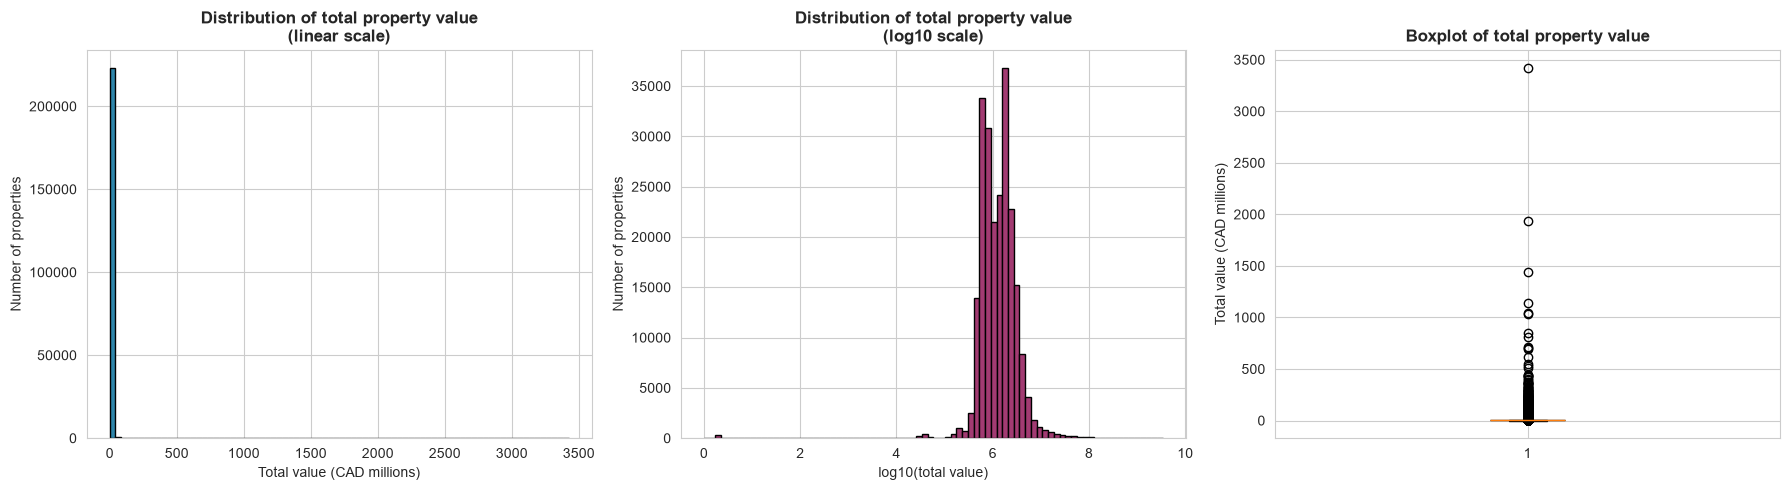

Key statistics:
  Median:  $1,295,000
  Mean:    $2,177,519
  Std:     $12,677,511
  Skewness: 129.48  (positive = right-skewed)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Linear histogram
axes[0].hist(df_2026['total_value'] / 1e6, bins=80, color='#2E86AB', edgecolor='black')
axes[0].set_title('Distribution of total property value\n(linear scale)', fontweight='bold')
axes[0].set_xlabel('Total value (CAD millions)')
axes[0].set_ylabel('Number of properties')

# 2. Log-scale histogram
axes[1].hist(np.log10(df_2026['total_value']), bins=80, color='#A23B72', edgecolor='black')
axes[1].set_title('Distribution of total property value\n(log10 scale)', fontweight='bold')
axes[1].set_xlabel('log10(total value)')
axes[1].set_ylabel('Number of properties')

# 3. Boxplot
axes[2].boxplot(df_2026['total_value'] / 1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#F18F01'))
axes[2].set_title('Boxplot of total property value', fontweight='bold')
axes[2].set_ylabel('Total value (CAD millions)')

plt.tight_layout()
plt.show()

# Print key statistics
print("Key statistics:")
print(f"  Median:  ${df_2026['total_value'].median():,.0f}")
print(f"  Mean:    ${df_2026['total_value'].mean():,.0f}")
print(f"  Std:     ${df_2026['total_value'].std():,.0f}")
print(f"  Skewness: {df_2026['total_value'].skew():.2f}  (positive = right-skewed)")

### Insight #1
> Vancouver's property value distribution is **highly right-skewed**. The mean is significantly higher than the median, indicating that a small number of very expensive properties pull the average up. For modeling, we will likely use **log-transformed target** or **robust regression** to handle this.

### A closer look: filtering extreme outliers for visualization

The linear histogram above is dominated by a handful of extreme outliers (industrial lots, malls, billion-dollar properties). To understand the distribution of **typical residential properties**, we filter the visualization to values between the 1st and 99th percentile.

⚠️ **Important:** this filter is **only for visualization**. The actual model will use the full dataset with proper handling (log-transform or robust regression).

Visualization range: $199,611 to $14,706,184
Properties shown: 219,085 (98.0% of total)
Properties excluded (extreme outliers): 4,472


C:\Users\racm1\AppData\Local\Temp\ipykernel_20384\1256054787.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_viz['total_value'] / 1e6, vert=True, patch_artist=True,


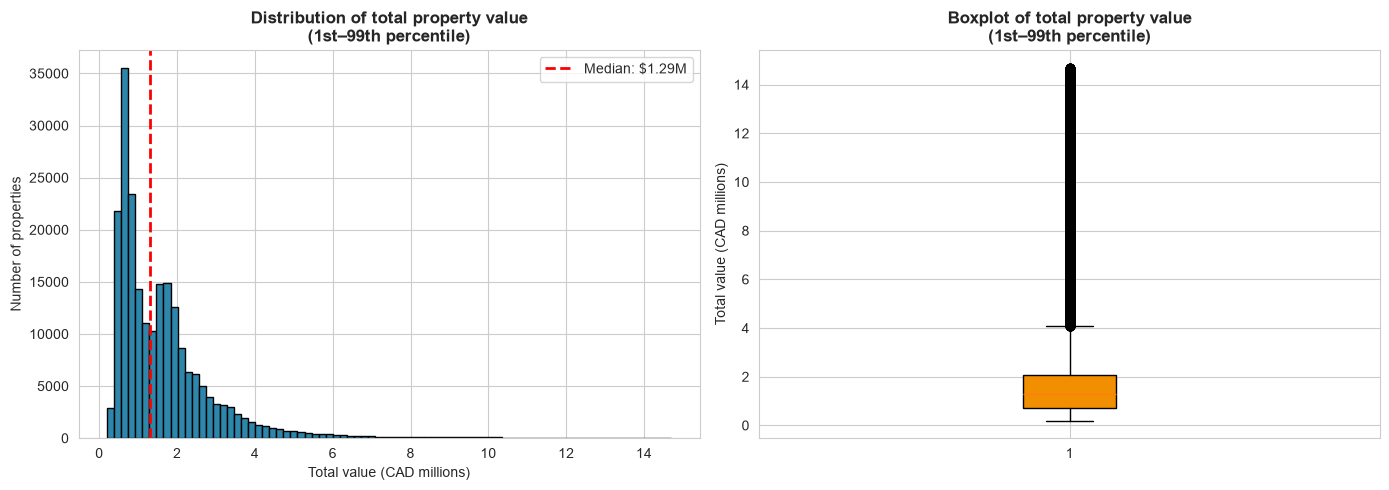

In [7]:
# Compute 1st and 99th percentile to remove extreme outliers ONLY for visualization
p01 = df_2026['total_value'].quantile(0.01)
p99 = df_2026['total_value'].quantile(0.99)

df_viz = df_2026[(df_2026['total_value'] >= p01) & (df_2026['total_value'] <= p99)]

print(f"Visualization range: ${p01:,.0f} to ${p99:,.0f}")
print(f"Properties shown: {len(df_viz):,} ({len(df_viz)/len(df_2026)*100:.1f}% of total)")
print(f"Properties excluded (extreme outliers): {len(df_2026) - len(df_viz):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cleaner histogram
axes[0].hist(df_viz['total_value'] / 1e6, bins=80, color='#2E86AB', edgecolor='black')
axes[0].axvline(df_viz['total_value'].median() / 1e6, color='red', linestyle='--',
                linewidth=2, label=f'Median: ${df_viz["total_value"].median()/1e6:.2f}M')
axes[0].set_title('Distribution of total property value\n(1st–99th percentile)', fontweight='bold')
axes[0].set_xlabel('Total value (CAD millions)')
axes[0].set_ylabel('Number of properties')
axes[0].legend()

# Cleaner boxplot
axes[1].boxplot(df_viz['total_value'] / 1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#F18F01'))
axes[1].set_title('Boxplot of total property value\n(1st–99th percentile)', fontweight='bold')
axes[1].set_ylabel('Total value (CAD millions)')

plt.tight_layout()
plt.show()

"El 99% de las propiedades de Vancouver están entre $X y $Y. El 1% restante son outliers extremos: centros comerciales, terrenos industriales o complejos hoteleros. Esto refuerza la necesidad de transformación logarítmica del target en el modelo."

## 3. Property types: STRATA vs LAND

Vancouver properties are classified by legal type:
- **LAND**: full land ownership (houses, lots)
- **STRATA**: condominium-style ownership (apartments, townhouses)
- Other categories

These have very different price structures.

             count  median_value  mean_value
legal_type                                  
STRATA      136656      787000.0    982803.0
LAND         86724     2260300.0   4004764.0
OTHER          177      708000.0  29291131.0



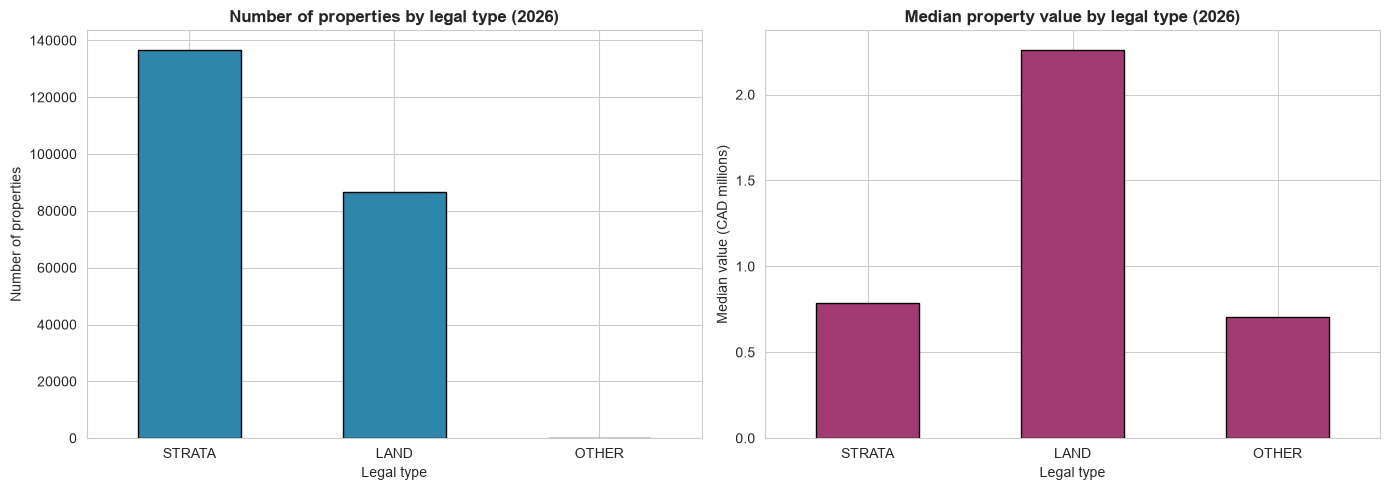

In [4]:
# Count and median price per legal_type
legal_summary = df_2026.groupby('legal_type').agg(
    count=('total_value', 'count'),
    median_value=('total_value', 'median'),
    mean_value=('total_value', 'mean')
).sort_values('count', ascending=False)

print(legal_summary.round(0))
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count per type
legal_summary['count'].plot(kind='bar', ax=axes[0], color='#2E86AB', edgecolor='black')
axes[0].set_title('Number of properties by legal type (2026)', fontweight='bold')
axes[0].set_xlabel('Legal type')
axes[0].set_ylabel('Number of properties')
axes[0].tick_params(axis='x', rotation=0)

# Median price per type
(legal_summary['median_value'] / 1e6).plot(kind='bar', ax=axes[1], color='#A23B72', edgecolor='black')
axes[1].set_title('Median property value by legal type (2026)', fontweight='bold')
axes[1].set_xlabel('Legal type')
axes[1].set_ylabel('Median value (CAD millions)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Insight #2
> STRATA properties (condos/apartments) dominate in volume but have lower median values than LAND properties. Any predictive model **must treat these segments separately** or include `legal_type` as a strong categorical feature.

## 4. The location factor: neighbourhoods

The #1 rule in real estate is *location, location, location*. Let's see how much price varies by neighbourhood.

TOP 10 most expensive neighbourhoods (by median value):
                    count  median_value
neighbourhood_code                     
008                  2517     4462000.0
010                  3273     3596000.0
006                  2177     3326000.0
001                  4373     3023700.0
003                  5026     2999000.0
004                  4039     2986000.0
005                  4403     2790000.0
028                  2027     2038000.0
024                  5220     1935650.0
016                  6919     1843200.0

BOTTOM 10 cheapest neighbourhoods (by median value):
                    count  median_value
neighbourhood_code                     
012                  6971     1326000.0
002                 15061     1285100.0
030                  9389     1032000.0
007                 13368      909000.0
023                 13023      889000.0
027                  9145      860000.0
013                 18989      824000.0
018                  5862      781000.0
026       

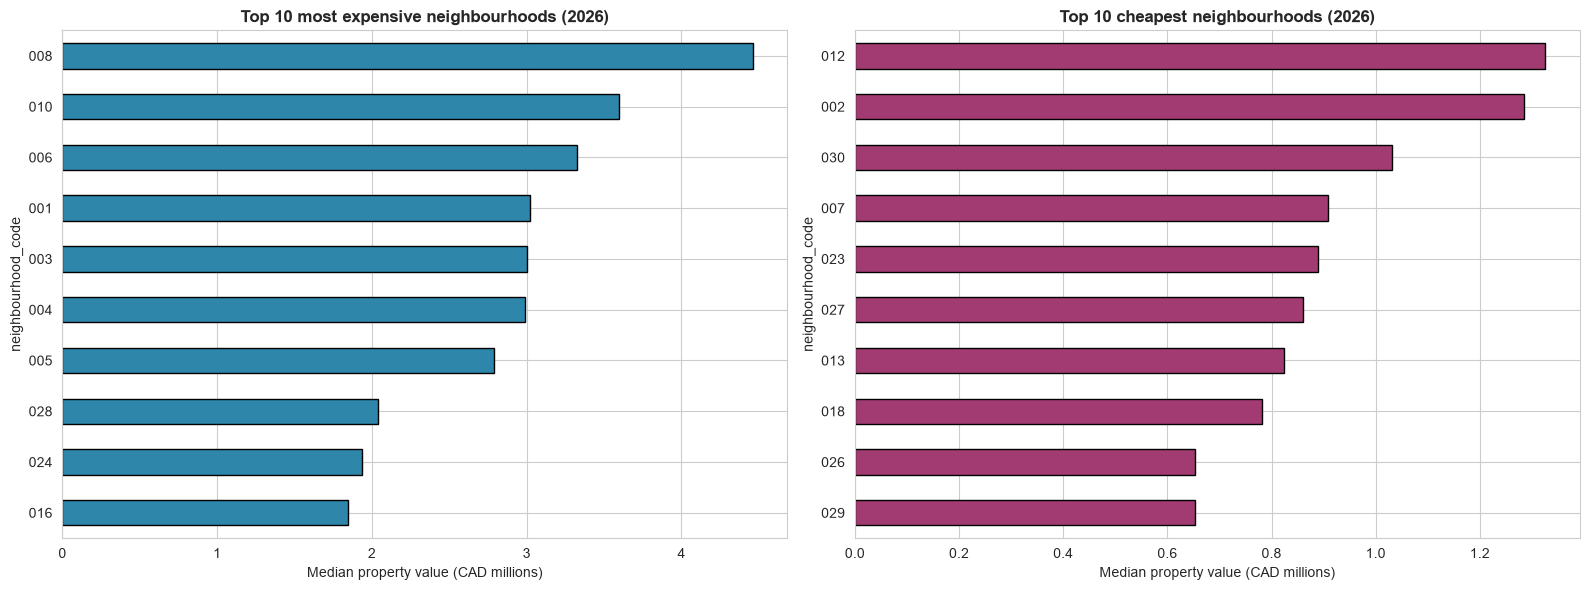


💡 Ratio: most expensive neighbourhood is 6.8x more expensive than cheapest.


In [5]:
# Median price per neighbourhood
neighbourhood_stats = df_2026.groupby('neighbourhood_code').agg(
    count=('total_value', 'count'),
    median_value=('total_value', 'median')
).query('count >= 100').sort_values('median_value', ascending=False)

# Top 10 most expensive and 10 cheapest
top_10 = neighbourhood_stats.head(10)
bottom_10 = neighbourhood_stats.tail(10)

print("TOP 10 most expensive neighbourhoods (by median value):")
print(top_10.round(0))
print()
print("BOTTOM 10 cheapest neighbourhoods (by median value):")
print(bottom_10.round(0))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

(top_10['median_value'] / 1e6).plot(kind='barh', ax=axes[0], color='#2E86AB', edgecolor='black')
axes[0].set_title('Top 10 most expensive neighbourhoods (2026)', fontweight='bold')
axes[0].set_xlabel('Median property value (CAD millions)')
axes[0].invert_yaxis()

(bottom_10['median_value'] / 1e6).plot(kind='barh', ax=axes[1], color='#A23B72', edgecolor='black')
axes[1].set_title('Top 10 cheapest neighbourhoods (2026)', fontweight='bold')
axes[1].set_xlabel('Median property value (CAD millions)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Ratio between most and least expensive
ratio = top_10['median_value'].iloc[0] / bottom_10['median_value'].iloc[-1]
print(f"\n💡 Ratio: most expensive neighbourhood is {ratio:.1f}x more expensive than cheapest.")

### Insight #3
> Neighbourhood is the **single strongest price driver**. The most expensive neighbourhood has a median value many times higher than the cheapest. This validates the inclusion of `neighbourhood_code` as the primary categorical feature in the model.

## 5. Property age: does it matter?

Conventional wisdom says newer = more expensive. But in Vancouver, many old houses in prime locations are tear-downs whose value is actually in the land.

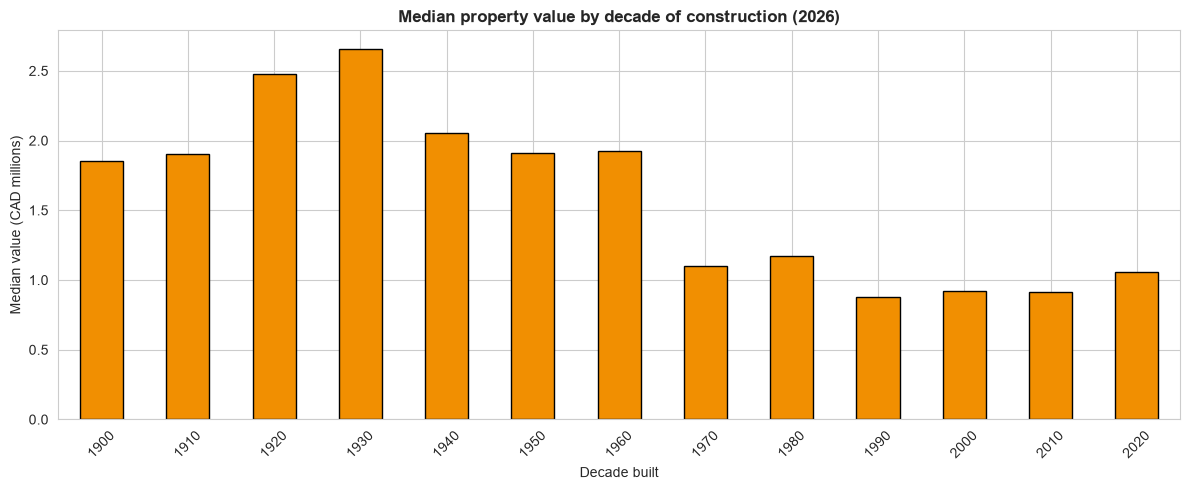

              count  median_value
decade_built                     
1900           1771     1854000.0
1910           9304     1901000.0
1920           8273     2480800.0
1930           4089     2656600.0
1940           7085     2055300.0
1950           7751     1908000.0
1960           7362     1925950.0
1970          16470     1100000.0
1980          24675     1171200.0
1990          44310      881000.0
2000          39498      924000.0
2010          36512      916000.0
2020           5588     1059000.0


In [6]:
# Convert year_built to numeric
df_2026['year_built_num'] = pd.to_numeric(df_2026['year_built'], errors='coerce')

# Filter realistic year range
df_age = df_2026[(df_2026['year_built_num'] >= 1900) &
                 (df_2026['year_built_num'] <= 2026)].copy()
df_age['property_age'] = 2026 - df_age['year_built_num']

# Median price per decade of construction
df_age['decade_built'] = (df_age['year_built_num'] // 10 * 10).astype(int)
decade_stats = df_age.groupby('decade_built').agg(
    count=('total_value', 'count'),
    median_value=('total_value', 'median')
).query('count >= 50')

fig, ax = plt.subplots(figsize=(12, 5))
(decade_stats['median_value'] / 1e6).plot(kind='bar', ax=ax, color='#F18F01', edgecolor='black')
ax.set_title('Median property value by decade of construction (2026)', fontweight='bold')
ax.set_xlabel('Decade built')
ax.set_ylabel('Median value (CAD millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(decade_stats.round(0))

### Insight #4
> Property age has a **strong but non-linear relationship** with price. Properties built **before 1960 are roughly 2x more valuable** than those built between 1970 and 2010. This is **not a building-quality effect** — it reflects that pre-1960 homes sit in Vancouver's most established neighbourhoods (Shaughnessy, Kerrisdale, Point Grey, West Point Grey) where **land value dominates total value**. The model must capture this — a linear `property_age` feature would miss the pattern entirely. Tree-based models (Random Forest, XGBoost) are recommended.

## 6. Land value vs improvement value

A unique aspect of Vancouver: the **land** is often worth more than the building on it. This ratio is a powerful indicator of redevelopment potential.

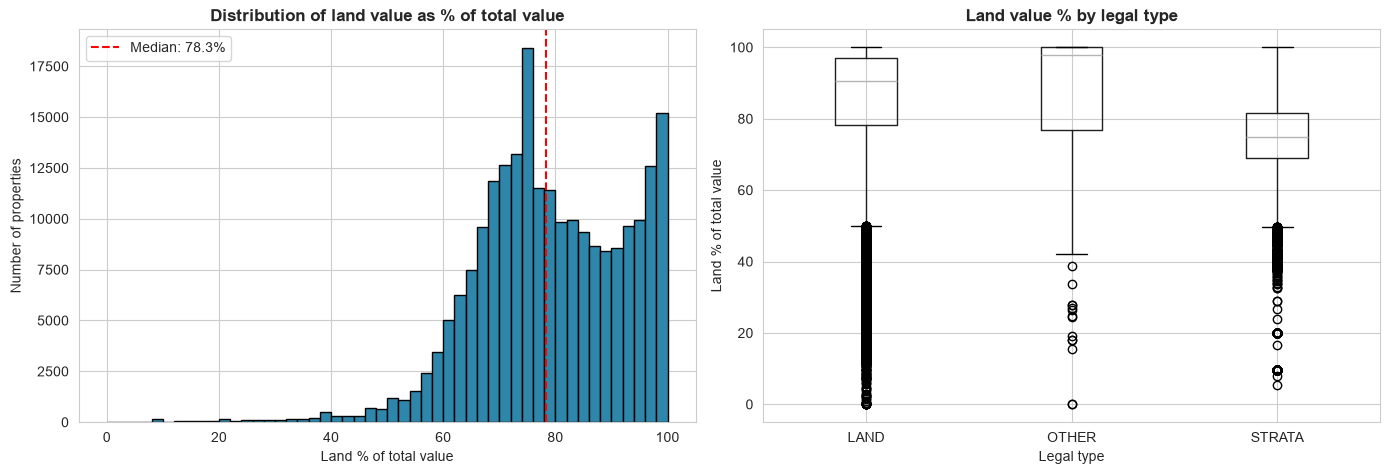

💡 Median land % across all properties: 78.3%
💡 Median land % for LAND type: 90.6%
💡 Median land % for STRATA type: 75.0%


In [8]:
df_2026['land_pct'] = df_2026['current_land_value'] / df_2026['total_value'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of land_pct
axes[0].hist(df_2026['land_pct'].dropna(), bins=50, color='#2E86AB', edgecolor='black')
axes[0].axvline(df_2026['land_pct'].median(), color='red', linestyle='--',
                label=f'Median: {df_2026["land_pct"].median():.1f}%')
axes[0].set_title('Distribution of land value as % of total value', fontweight='bold')
axes[0].set_xlabel('Land % of total value')
axes[0].set_ylabel('Number of properties')
axes[0].legend()

# Land % by legal_type
df_2026.boxplot(column='land_pct', by='legal_type', ax=axes[1])
axes[1].set_title('Land value % by legal type', fontweight='bold')
axes[1].set_xlabel('Legal type')
axes[1].set_ylabel('Land % of total value')
plt.suptitle('')  # Remove auto suptitle

plt.tight_layout()
plt.show()

print(f"💡 Median land % across all properties: {df_2026['land_pct'].median():.1f}%")
print(f"💡 Median land % for LAND type: {df_2026[df_2026['legal_type']=='LAND']['land_pct'].median():.1f}%")
print(f"💡 Median land % for STRATA type: {df_2026[df_2026['legal_type']=='STRATA']['land_pct'].median():.1f}%")

### Insight #5
> Vancouver's market is **land-driven**. For LAND-type properties, the land typically accounts for 70%+ of total value, meaning **buildings are often "tear-down" candidates** for redevelopment. This is a Vancouver-specific phenomenon driven by zoning and demand.

## 7. Temporal trends: price evolution 2020–2026

Let's see how Vancouver property values have evolved across the 7 years in the dataset.

                 median_value  mean_value   count
report_year_num                                  
2020                1116600.0   2056070.0  212453
2021                1187260.0   2076318.0  213616
2022                1305000.0   2292265.0  216726
2023                1378000.0   2375320.0  218076
2024                1379000.0   2367874.0  219708
2025                1368000.0   2340557.0  221887
2026                1295000.0   2177519.0  223557


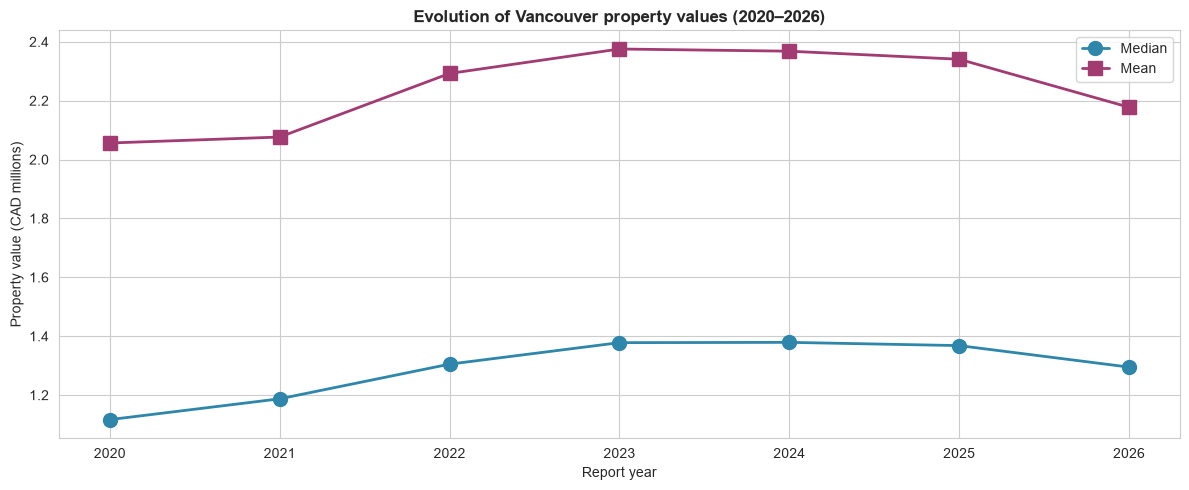


💡 Median property value growth 2020 → 2026: +16.0%


In [9]:
# Median value per year
df_clean = df[df['total_value'] > 0].copy()
df_clean['report_year_num'] = pd.to_numeric(df_clean['report_year'], errors='coerce')

yearly_evolution = df_clean.groupby('report_year_num').agg(
    median_value=('total_value', 'median'),
    mean_value=('total_value', 'mean'),
    count=('total_value', 'count')
).round(0)

print(yearly_evolution)

fig, ax = plt.subplots(figsize=(12, 5))
(yearly_evolution['median_value'] / 1e6).plot(kind='line', marker='o', linewidth=2,
                                                markersize=10, ax=ax, color='#2E86AB',
                                                label='Median')
(yearly_evolution['mean_value'] / 1e6).plot(kind='line', marker='s', linewidth=2,
                                              markersize=10, ax=ax, color='#A23B72',
                                              label='Mean')
ax.set_title('Evolution of Vancouver property values (2020–2026)', fontweight='bold')
ax.set_xlabel('Report year')
ax.set_ylabel('Property value (CAD millions)')
ax.legend()
plt.tight_layout()
plt.show()

# Total growth
growth_pct = (yearly_evolution['median_value'].iloc[-1] / yearly_evolution['median_value'].iloc[0] - 1) * 100
print(f"\n💡 Median property value growth 2020 → 2026: {growth_pct:+.1f}%")

### Insight #6
> Property values in Vancouver have evolved significantly between 2020 and 2026, reflecting both organic market growth and broader economic factors (pandemic, interest rates, immigration). The presence of multi-year data allows the model to potentially capture temporal patterns.

## 8. Correlation matrix between numeric features

Final check: how do the numeric variables relate to each other and to the target?

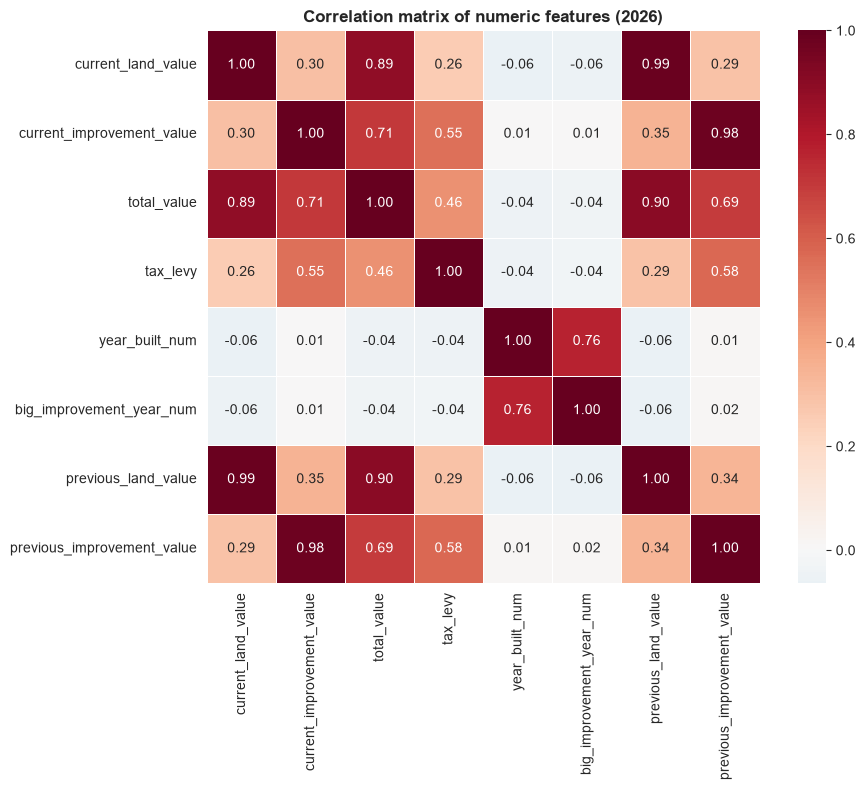

In [10]:
# Select numeric features (convert year columns first)
df_corr = df_2026.copy()
df_corr['year_built_num'] = pd.to_numeric(df_corr['year_built'], errors='coerce')
df_corr['big_improvement_year_num'] = pd.to_numeric(df_corr['big_improvement_year'], errors='coerce')

numeric_cols = ['current_land_value', 'current_improvement_value', 'total_value',
                'tax_levy', 'year_built_num', 'big_improvement_year_num',
                'previous_land_value', 'previous_improvement_value']

corr_matrix = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix of numeric features (2026)', fontweight='bold')
plt.tight_layout()
plt.show()